# Olasılıksal Dil Modelleri Giriş

* Olasılıksal dil modelleri, dilin yapısını ve düzenini anlamak ve modellemek için kullanılan istatistiksel yöntemlerdir.

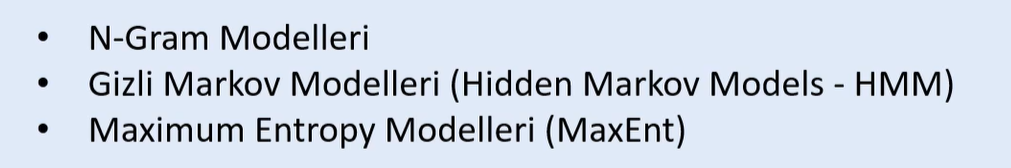

## N-Gram Modelleri

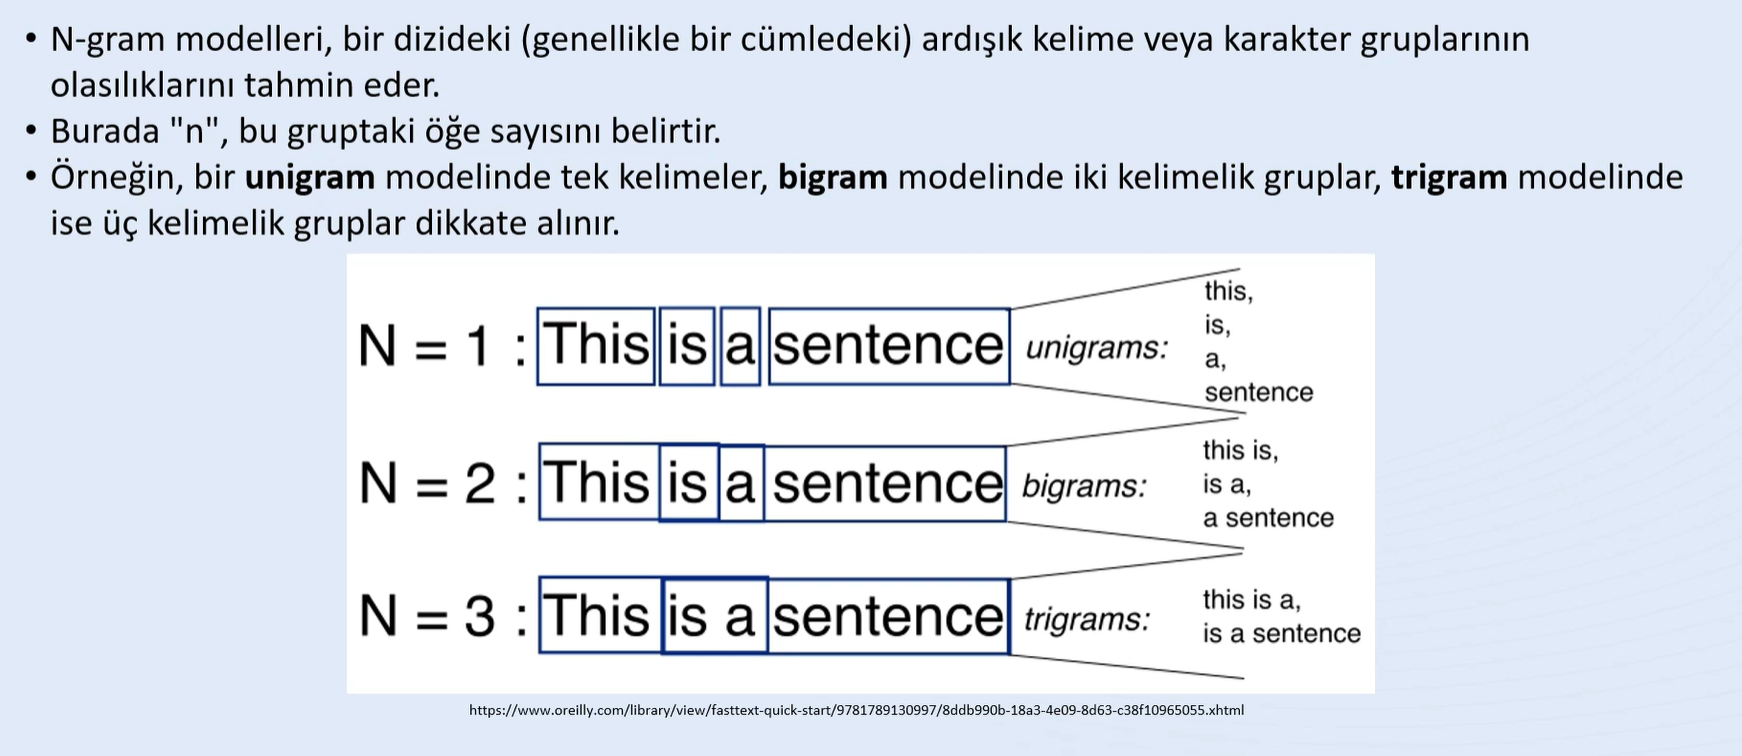

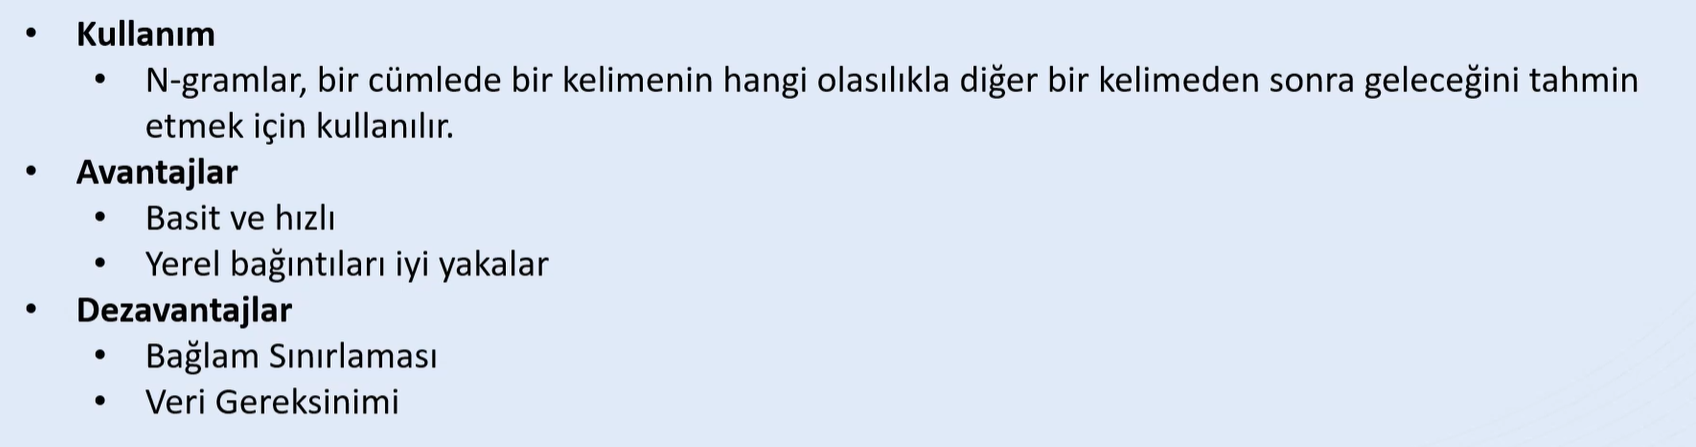

In [117]:
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

In [118]:
# Örnek veri seti
corpus = [
    "I love you",
    "I love apple",
    "I love programming",
    "I love you and you love me",
    "You love me",
    "She loves apple",
    "They love you",
]

In [119]:
# Tokenize ile metinleri tokene çevirme
tokens = [word_tokenize(sentence.lower()) for sentence in corpus]
tokens

[['i', 'love', 'you'],
 ['i', 'love', 'apple'],
 ['i', 'love', 'programming'],
 ['i', 'love', 'you', 'and', 'you', 'love', 'me'],
 ['you', 'love', 'me'],
 ['she', 'loves', 'apple'],
 ['they', 'love', 'you']]

In [123]:
# n-gram -> 2 seçiyoruz. yani bigram.
bigrams = []
for token_list in tokens:
  bigrams.extend(list(ngrams(token_list, 2)))
bigrams

[('i', 'love'),
 ('love', 'you'),
 ('i', 'love'),
 ('love', 'apple'),
 ('i', 'love'),
 ('love', 'programming'),
 ('i', 'love'),
 ('love', 'you'),
 ('you', 'and'),
 ('and', 'you'),
 ('you', 'love'),
 ('love', 'me'),
 ('you', 'love'),
 ('love', 'me'),
 ('she', 'loves'),
 ('loves', 'apple'),
 ('they', 'love'),
 ('love', 'you')]

In [124]:
# bigramslardaki frekansları sayma
bigram_frequencies = Counter(bigrams)
bigram_frequencies

Counter({('i', 'love'): 4,
         ('love', 'you'): 3,
         ('love', 'apple'): 1,
         ('love', 'programming'): 1,
         ('you', 'and'): 1,
         ('and', 'you'): 1,
         ('you', 'love'): 2,
         ('love', 'me'): 2,
         ('she', 'loves'): 1,
         ('loves', 'apple'): 1,
         ('they', 'love'): 1})

* Yukarıda frekansları sayarken her bir tokendan sonra hangi kelimenin daha fazla gelebilme olasılığını görmüş olduk.

In [126]:
# Burada ise n-gram -> 3 seçiyoruz. Yani trigram.
trigrams = []
for token_list in tokens:
  trigrams.extend(list(ngrams(token_list, 3)))
trigrams

[('i', 'love', 'you'),
 ('i', 'love', 'apple'),
 ('i', 'love', 'programming'),
 ('i', 'love', 'you'),
 ('love', 'you', 'and'),
 ('you', 'and', 'you'),
 ('and', 'you', 'love'),
 ('you', 'love', 'me'),
 ('you', 'love', 'me'),
 ('she', 'loves', 'apple'),
 ('they', 'love', 'you')]

In [127]:
trigram_frequencies = Counter(trigrams)
trigram_frequencies

Counter({('i', 'love', 'you'): 2,
         ('i', 'love', 'apple'): 1,
         ('i', 'love', 'programming'): 1,
         ('love', 'you', 'and'): 1,
         ('you', 'and', 'you'): 1,
         ('and', 'you', 'love'): 1,
         ('you', 'love', 'me'): 2,
         ('she', 'loves', 'apple'): 1,
         ('they', 'love', 'you'): 1})

In [132]:
# Soru: "I love" bigramından sonra "you" ve "apple" gelme olasılığı nedir? Bu soruyu elle kendimiz deneyelim.
bigram = ("i", "love")
probability_you = trigram_frequencies[("i", "love", "you")]/bigram_frequencies[bigram]  # You olmas olasılığı
probability_apple = trigram_frequencies[("i", "love", "apple")]/bigram_frequencies[bigram]  # Apple olma olasılığı

In [133]:
print("You Kelimesini olma olasılığı: ", probability_you)
print("Apple Kelimesini olma olasılığı: ", probability_apple)

You Kelimesini olma olasılığı:  0.5
Apple Kelimesini olma olasılığı:  0.25


## Hidden Markov Models (HMM)

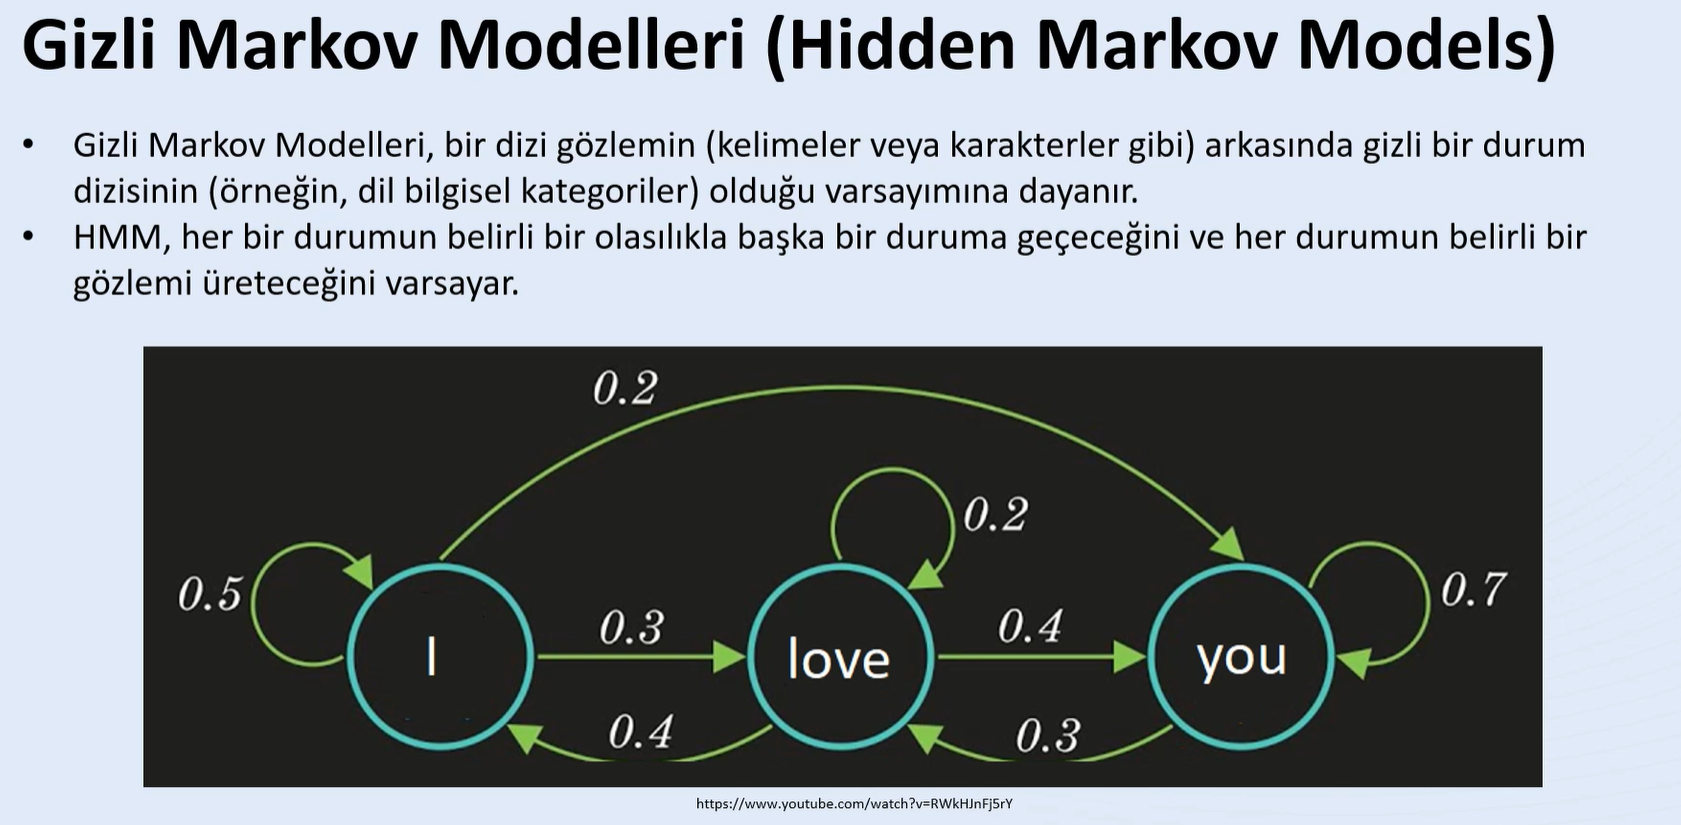

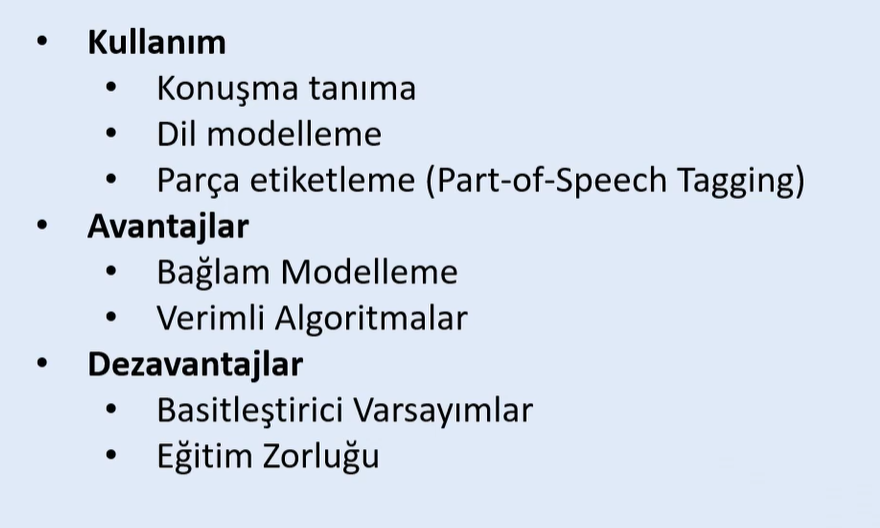

In [134]:
import nltk
from nltk.tag import hmm

In [135]:
# Örnek veri seti oluşturma
train_data = [
    [("I", "PRP"), ("am", "VBP"), ("a", "DT"), ("student", "NN")],
    [("You", "PRP"), ("are", "VBP"), ("a", "DT"), ("teacher", "NN")]
]

In [136]:
# hmm training
trainer = hmm.HiddenMarkovModelTrainer()
hmm_tagger = trainer.train(train_data)
hmm_tagger

<HiddenMarkovModelTagger 4 states and 7 output symbols>

In [139]:
# test etmek için yeni bir cümle oluşturalım.
test_sentence = "I am a teacher".split()
tags = hmm_tagger.tag(test_sentence)
print("Etiketli Cümle: ",tags)

Etiketli Cümle:  [('I', 'PRP'), ('am', 'VBP'), ('a', 'DT'), ('teacher', 'NN')]


In [140]:
# Şimdi HMM'i nltk'ey kütüphanesi içerisinde bulunan dataseti üzerinde test edelim
from nltk.corpus import conll2000

In [141]:
# Gerekli veri setini indirme
nltk.download("conll2000")

[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.


True

In [142]:
# conll veri setini yükleme işlemi
train_data = conll2000.tagged_sents("train.txt")
test_data = conll2000.tagged_sents("test.txt")

In [143]:
# hmm eğitimi(training)
trainer = hmm.HiddenMarkovModelTrainer()
hmm_tagger = trainer.train(train_data)

In [144]:
# Test etme
test_sentence = "I am not going to park".split()
tags = hmm_tagger.tag(test_sentence)
tags

[('I', 'PRP'),
 ('am', 'VBP'),
 ('not', 'RB'),
 ('going', 'VBG'),
 ('to', 'TO'),
 ('park', 'VB')]

## Maximum Entropy Models (MaxEnt)

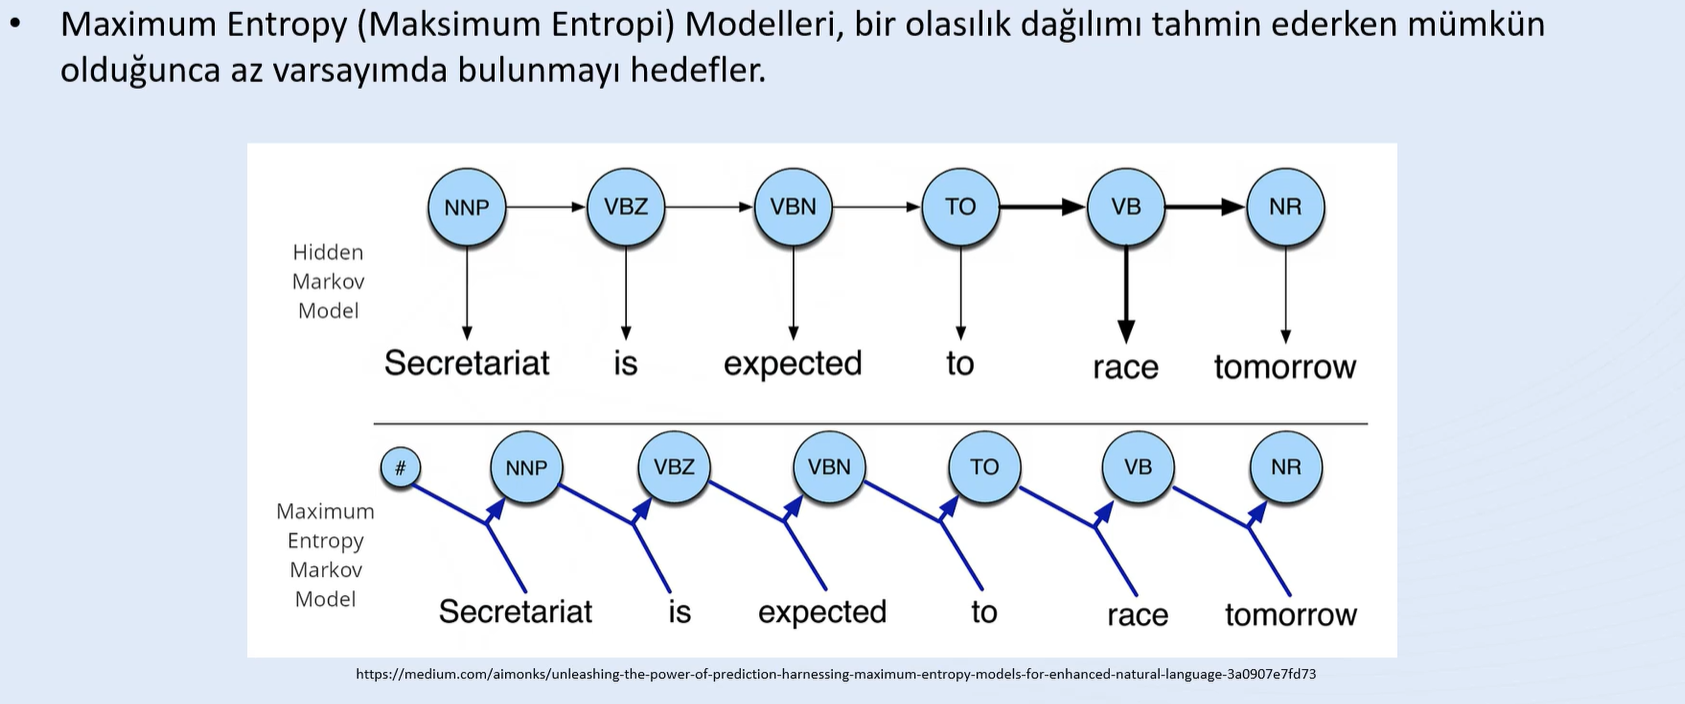

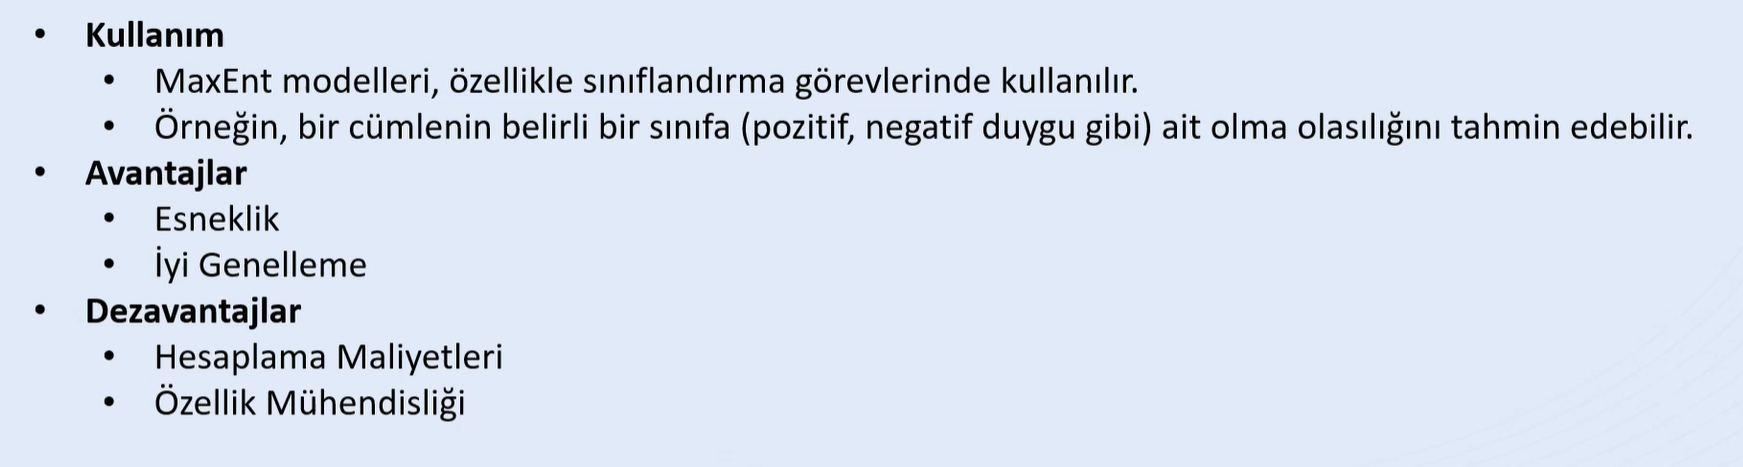

In [145]:
from nltk.classify import MaxentClassifier

In [146]:
# Eğitim Veri Seti
train_data = [
    ({"Love": True, "amazing": True}, "positive"),
    ({"hate": True, "terrible": True}, "negative"),
    ({"happy": True, "joy": True}, "positive"),
    ({"sad": True, "depressed": True}, "negative")
]

In [148]:
# Maximum entropy classifier training
classifier = MaxentClassifier.train(train_data, max_iter = 10)
classifier

  ==> Training (10 iterations)

      Iteration    Log Likelihood    Accuracy
      ---------------------------------------
             1          -0.69315        0.500
             2          -0.40547        1.000
             3          -0.28768        1.000
             4          -0.22314        1.000
             5          -0.18232        1.000
             6          -0.15415        1.000
             7          -0.13353        1.000
             8          -0.11778        1.000
             9          -0.10536        1.000
         Final          -0.09531        1.000


<ConditionalExponentialClassifier: 2 labels, 8 features>

In [151]:
# test kısmı
test_sentence = "I love amazing movie"
features = {word: (word in test_sentence.split()) for word in ["Love", "amazing", "hate", "terrible", "happy", "joy", "sad", "depressed"]}
features

{'Love': False,
 'amazing': True,
 'hate': False,
 'terrible': False,
 'happy': False,
 'joy': False,
 'sad': False,
 'depressed': False}

In [152]:
label = classifier.classify(features)
print(label)


positive
